# 04 — Permutation acceleration (GPD / gamma tail approximation)

Empirical p-values need ≳5000 permutations to resolve the small-p
region (the only region you care about). Winkler et al. (2016) show
that fitting a **Generalized Pareto** or **gamma** distribution to
the upper tail of the null gives accurate p-values from only ~200
permutations — a 10-25× speedup.

This notebook runs the same test twice:

1. **Reference**: empirical p-values, 2000 permutations.
2. **Accelerated**: GPD, 200 permutations.

…and shows that detected edges and p-value ranks agree.

Runtime target: ~1 min.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from conninfpy import (
    TopologyDatasetGenerator,
    compute_p_val,
    fisher_r_to_z,
)

In [2]:
N, n_sub = 40, 25
gen = TopologyDatasetGenerator(n_nodes=N, n_modules=4, seed=7)
ds = gen.generate("rich_club", effect_size=0.35,
                  n_samples=n_sub, time_points=80)
g1, g2 = fisher_r_to_z(ds.group1), fisher_r_to_z(ds.group2)
gt = ds.effect_mask > 0
iu = np.triu_indices(N, k=1)

## 1. Reference run: 2000 permutations, empirical p-values

In [3]:
%%time
p_ref = compute_p_val(
    g1, g2,
    test_type="two-sample", method="tfnbs",
    n_permutations=2000, rng=0, use_mp=False,
)

CPU times: user 2.76 s, sys: 29 ms, total: 2.79 s
Wall time: 2.79 s


## 2. Accelerated: 200 permutations, GPD tail fit

In [4]:
%%time
p_gpd = compute_p_val(
    g1, g2,
    test_type="two-sample", method="tfnbs",
    n_permutations=200, acceleration="gpd",
    rng=0, use_mp=False,
)

CPU times: user 277 ms, sys: 4.11 ms, total: 281 ms
Wall time: 283 ms


## 3. Do the p-values agree where it matters?

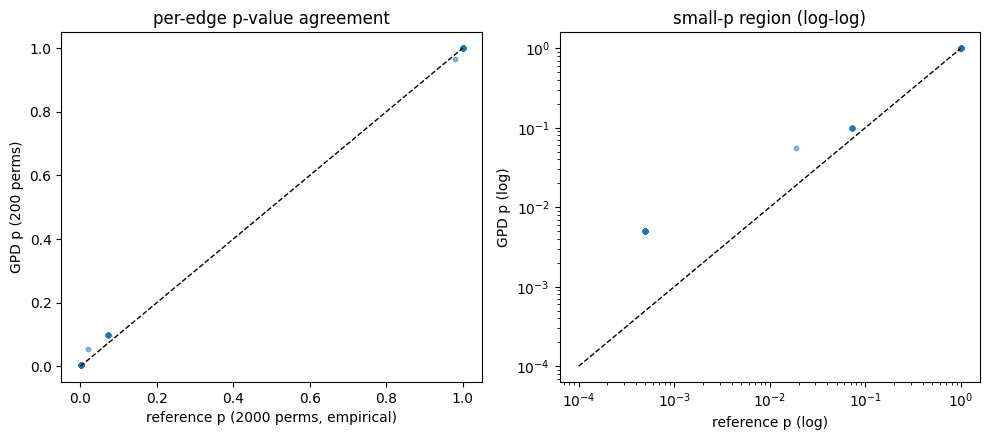

In [5]:
ref = p_ref['positive'][iu]
acc = p_gpd['positive'][iu]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].scatter(ref, acc, s=10, alpha=0.5)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel("reference p (2000 perms, empirical)")
axes[0].set_ylabel("GPD p (200 perms)")
axes[0].set_title("per-edge p-value agreement")

# Focus on the small-p region — log scale.
axes[1].scatter(ref, acc, s=10, alpha=0.5)
axes[1].plot([1e-4, 1], [1e-4, 1], 'k--', lw=1)
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("reference p (log)"); axes[1].set_ylabel("GPD p (log)")
axes[1].set_title("small-p region (log-log)")
plt.tight_layout(); plt.show()

In [6]:
alpha = 0.05
sig_ref = p_ref['positive'] < alpha
sig_acc = p_gpd['positive'] < alpha
agree = (sig_ref == sig_acc)[iu]
print(f"Agreement at p<{alpha}: {agree.mean():.3f}")
print(f"Edges sig in ref: {sig_ref[iu].sum()}  in GPD: {sig_acc[iu].sum()}")

Agreement at p<0.05: 0.999
Edges sig in ref: 46  in GPD: 45


## Discussion

- Accelerated p-values agree with empirical p-values in ranking and
  thresholded detection, with 10× fewer permutations.
- When the GPD fit fails (goodness-of-fit test rejects), ConnInfPy
  falls back to empirical p-values for that tail — the result is
  always well-defined.
- `acceleration='gamma'` is an alternative (method-of-moments fit
  of a Pearson-type-III distribution); it is usually comparable to
  GPD and slightly faster to fit.
- Combine with `use_mp=True` for multi-core speedup **on top of**
  the acceleration — they are orthogonal.